# E-commerce Orders Query Chatbot using Agentic AI

### A teaching-first LangGraph + SQLite + Streamlit build

This notebook is designed for a 90-minute webinar. It moves from the business problem to a working, testable agent and then to deployment. The default path uses no API key, so every learner can run it. An optional LLM-assisted path is included at the end.

> **Safety boundary:** This is a synthetic teaching database. Production customer support requires authenticated identity, governed APIs, privacy controls, observability, and human approval for consequential actions.

## Learning outcomes

By the end, you will be able to:

1. distinguish a chatbot response from an agentic workflow;
2. model agent state, nodes, tools, and routing with LangGraph;
3. ground answers in a relational order database;
4. enforce object-level authorization before retrieval;
5. trace and evaluate the workflow across positive and adversarial cases;
6. package the same project for GitHub and Streamlit Community Cloud.

### 90-minute pathway

**Foundations (15 min) → Data and tools (15 min) → Agent build and demo (30 min) → Safety and evaluation (10 min) → Streamlit deployment (12 min) → Challenge and close (8 min)**

## 1. Environment and reproducibility

The project pins dependencies in `requirements.txt`. A pinned environment reduces the chance that a live workshop fails because an API changed overnight. Python 3.11 or 3.12 is recommended for local and cloud parity.

In [1]:
# EXPECTED OUTPUT: Python version, four installed package versions, and the notebook working directory.
# INTERPRETATION: Successful version lines confirm the runtime is ready. The working directory should be the project root so relative imports and data paths behave exactly as they will on Streamlit Cloud.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

from pathlib import Path
import sys
import importlib.metadata as metadata

packages = ["langgraph", "streamlit", "pandas", "matplotlib"]
print("Python:", sys.version.split()[0])
for package in packages:
    print(f"{package}: {metadata.version(package)}")
print("Working directory:", Path.cwd())


Python: 3.13.5
langgraph: 1.2.11
streamlit: 1.45.1
pandas: 2.2.3
matplotlib: 3.10.0
Working directory: C:\Users\Kshat\Downloads\E-commerce_Orders_Agentic_AI_Webinar_Complete_Kit\webinar_kit


In [2]:
# EXPECTED OUTPUT: `Database exists: True` followed by an absolute path ending in `data/orders.db`.
# INTERPRETATION: True confirms both the package import and file path strategy work. An absolute module-relative path avoids the common cloud failure caused by launching an app from a different directory.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src.data import DB_PATH, database_summary, get_order, list_customer_orders, customer_owns_order
from src.chatbot import GRAPH, ask, trace_as_json

print("Database exists:", DB_PATH.exists())
print("Database path:", DB_PATH)


Database exists: True
Database path: C:\Users\Kshat\Downloads\E-commerce_Orders_Agentic_AI_Webinar_Complete_Kit\webinar_kit\data\orders.db


## 2. Why this use case needs an agent

An LLM can phrase an answer, but it does not inherently know the current order state, the signed-in customer, or the return policy. An agentic workflow makes those dependencies explicit:

```mermaid
flowchart LR
    Q[Customer question] --> G[Guardrail]
    G --> C[Classify and extract]
    C --> A[Authorize]
    A --> T[Read-only tools]
    T --> P[Policy]
    P --> R[Grounded response]
```

The key design choice is **control before fluency**: authorization and data tools determine what may be known; language generation determines how it is communicated.

## 3. Inspect the data before building the agent

The sample has four normalized tables. The agent should never invent records, and it should never expose one customer's order to another customer.

,table,rows
0,customers,5
1,orders,10
2,order_items,21
3,products,5


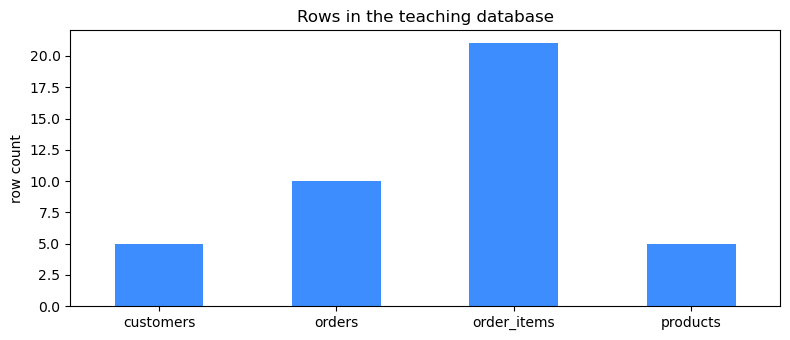

In [3]:
# EXPECTED OUTPUT: A four-row table and bar chart showing 5 customers, 10 orders, 21 order items, and 5 products.
# INTERPRETATION: The chart shows why `order_items` is larger: an order can contain multiple products. These are actual database counts, not synthetic performance metrics.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

summary = database_summary()
summary_df = pd.DataFrame(summary.items(), columns=["table", "rows"])
display(summary_df)

ax = summary_df.plot.bar(x="table", y="rows", legend=False, color="#3D8DFF", figsize=(8, 3.5))
ax.set_title("Rows in the teaching database")
ax.set_ylabel("row count")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [4]:
# EXPECTED OUTPUT: Four `CREATE TABLE` statements for customers, order_items, orders, and products.
# INTERPRETATION: Primary keys establish record identity; foreign keys describe joins. The schema reveals which fields are safe to retrieve and which identifiers must be scoped by customer.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

import sqlite3

with sqlite3.connect(DB_PATH) as connection:
    schema_rows = connection.execute(
        "SELECT name, sql FROM sqlite_master WHERE type='table' ORDER BY name"
    ).fetchall()

for table_name, create_sql in schema_rows:
    print(f"\n--- {table_name} ---")
    print(create_sql)



--- customers ---
CREATE TABLE customers (
            customer_id INTEGER PRIMARY KEY,
            name TEXT NOT NULL,
            email TEXT UNIQUE NOT NULL
        )

--- order_items ---
CREATE TABLE order_items (
            order_id TEXT,
            product_id TEXT,
            quantity INTEGER NOT NULL,
            price_at_purchase REAL NOT NULL,
            PRIMARY KEY (order_id, product_id),
            FOREIGN KEY (order_id) REFERENCES orders(order_id),
            FOREIGN KEY (product_id) REFERENCES products(product_id)
        )

--- orders ---
CREATE TABLE orders (
            order_id TEXT PRIMARY KEY,
            order_date TEXT NOT NULL,
            status TEXT NOT NULL,
            delivery_date TEXT,
            total_amount REAL NOT NULL,
            shipping_address TEXT,
            payment_method TEXT,
            customer_id INTEGER,
            FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
        )

--- products ---
CREATE TABLE products (
     

In [5]:
# EXPECTED OUTPUT: A table containing only orders whose `customer_id` is 3, ordered newest first.
# INTERPRETATION: This narrow tool contract is easier to audit than giving a model unrestricted SQL access. The model requests a business operation; the tool controls the query.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

customer_three_orders = list_customer_orders(3)
display(pd.DataFrame(customer_three_orders))


,order_id,order_date,status,delivery_date,total_amount
0,ORD1008,2025-10-24,Shipped,None,299.99
1,ORD1004,2025-10-01,Returned,None,49.99
2,ORD1005,2025-09-18,Cancelled,None,1448.98


In [6]:
# EXPECTED OUTPUT: One order header dictionary and an item table for ORD1001.
# INTERPRETATION: The tool joins customer, order, item, and product facts. The response node can now be grounded in returned fields rather than model memory.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

order = get_order("ORD1001")
print({key: value for key, value in order.items() if key != "items"})
display(pd.DataFrame(order["items"]))


{'order_id': 'ORD1001', 'order_date': '2025-10-05', 'status': 'Processing', 'delivery_date': None, 'total_amount': 1598.99, 'shipping_address': '789 Pine Ln, Somewhere, USA', 'payment_method': 'Bank Transfer', 'customer_id': 5, 'customer_name': 'Ethan Hunt', 'customer_email': 'ethan.h@example.com'}


,product_id,name,category,return_policy,warranty_period,quantity,price_at_purchase
0,P003,Ergonomic Office Chair,Furniture,90 days,5 years,2,450.00
1,P002,Noise-Cancelling Headphones,Electronics,60 days,2 years,2,199.50
2,P001,Smartwatch X,Electronics,30 days,1 year,1,299.99


### Tool-design pattern

- **Narrow contract:** `get_order(order_id)` expresses a business operation.
- **Parameterized SQL:** placeholders separate values from SQL syntax.
- **Read-only connection:** the database URI uses `mode=ro`.
- **Module-relative path:** deployment does not depend on the launch directory.
- **No secret in code:** provider credentials belong in environment or Streamlit secrets.

These controls reduce risk before prompt engineering enters the picture.

In [7]:
# EXPECTED OUTPUT: `Correct owner: True` and `Wrong owner: False`.
# INTERPRETATION: The same order exists in both checks; access changes only because the customer scope changes. This is object-level authorization, and it must occur before the response exposes order data.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

print("Correct owner:", customer_owns_order(5, "ORD1001"))
print("Wrong owner:  ", customer_owns_order(1, "ORD1001"))


Correct owner: True
Wrong owner:   False


## 4. Agent state: the shared working memory

LangGraph passes a typed state between nodes. In this project the state includes the query, extracted IDs, intent, authorization result, retrieved records, policy calculation, response, and trace. The trace field uses an additive reducer so each node appends evidence rather than overwriting prior events.

In [8]:
# EXPECTED OUTPUT: The `AgentState` TypedDict source with fields such as query, intent, authorized, order, response, and trace.
# INTERPRETATION: The state is the contract between nodes. Optional fields allow the graph to fill information progressively; typed names make node responsibilities visible and testable.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

import inspect
from src import chatbot

print(inspect.getsource(chatbot.AgentState))


class AgentState(TypedDict, total=False):
    query: str
    customer_id: int | None
    order_id: str | None
    intent: Intent
    authorized: bool
    order: dict[str, Any] | None
    orders: list[dict[str, Any]]
    policy: dict[str, Any]
    response: str
    trace: Annotated[list[dict[str, str]], operator.add]
    mode: str
    error: str | None



## 5. Nodes: one bounded responsibility each

Each node should be small enough to explain, test, and monitor independently. The next cells inspect the exact code used by the Streamlit app.

In [9]:
# EXPECTED OUTPUT: The guardrail function source.
# INTERPRETATION: The guardrail rejects empty input and obvious database-write instructions before any classification or retrieval. It is a teaching control, not a complete security product.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

print(inspect.getsource(chatbot.guardrail_node))


def guardrail_node(state: AgentState) -> AgentState:
    query = (state.get("query") or "").strip()
    blocked = any(token in query.lower() for token in ("drop table", "delete from", "insert into", "update orders"))
    if not query:
        return {"error": "Please enter a question.", "trace": [_event("guardrail", "Rejected an empty request.")]}
    if blocked:
        return {
            "error": "I can answer order questions, but I cannot modify the database.",
            "trace": [_event("guardrail", "Blocked a database-write instruction.")],
        }
    return {"trace": [_event("guardrail", "Input accepted; no write instruction detected.")]}



In [10]:
# EXPECTED OUTPUT: The classifier node source, including the optional structured-output LLM path and deterministic fallback.
# INTERPRETATION: The node prefers structured LLM output only when configured, then normalizes identifiers. If the provider is unavailable, the fallback preserves the webinar outcome.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

print(inspect.getsource(chatbot.classify_node))


def classify_node(state: AgentState) -> AgentState:
    llm_result = _llm_classification(state["query"]) if state.get("mode") == "LLM-assisted" else None
    regex_customer, regex_order = _extract_ids(state["query"])
    if llm_result:
        intent = llm_result["intent"]
        customer_id = llm_result.get("customer_id") or regex_customer
        order_id = (llm_result.get("order_id") or regex_order)
        if order_id:
            order_id = re.sub(r"[^A-Z0-9]", "", order_id.upper())
        method = "LLM structured output"
    else:
        intent = _deterministic_intent(state["query"], regex_order)
        customer_id, order_id = regex_customer, regex_order
        method = "deterministic fallback"
    detail = f"Intent={intent}; customer_id={customer_id}; order_id={order_id}; via {method}."
    return {
        "intent": intent,
        "customer_id": customer_id,
        "order_id": order_id,
        "trace": [_event("classify", detail)],
    }



In [11]:
# EXPECTED OUTPUT: Authorization and retrieval node source code.
# INTERPRETATION: Authorization produces a decision before retrieval. Retrieval skips itself when authorization fails, making the security boundary visible in both code and trace.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

print(inspect.getsource(chatbot.authorize_node))
print(inspect.getsource(chatbot.retrieve_node))


def authorize_node(state: AgentState) -> AgentState:
    customer_id, order_id = state.get("customer_id"), state.get("order_id")
    if state.get("intent") == "order_list":
        allowed = customer_id is not None
        detail = "Customer identifier supplied for scoped order lookup." if allowed else "Customer identifier is missing."
    elif order_id and customer_id is not None:
        allowed = customer_owns_order(customer_id, order_id)
        detail = "Ownership verified." if allowed else "Ownership check failed."
    else:
        allowed = False
        detail = "Both customer ID and order ID are required for this request."
    return {"authorized": allowed, "trace": [_event("authorize", detail)]}

def retrieve_node(state: AgentState) -> AgentState:
    if not state.get("authorized"):
        return {"trace": [_event("retrieve", "Skipped because authorization did not pass.")]}
    if state.get("intent") == "order_list":
        orders = list_customer_orders(state["customer_id"

In [12]:
# EXPECTED OUTPUT: Policy and response node source code.
# INTERPRETATION: Policy calculations stay deterministic and auditable. The response uses retrieved fields; it does not fabricate delivery dates or automatically execute a return.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

print(inspect.getsource(chatbot.policy_node))
print(inspect.getsource(chatbot.respond_node))


def policy_node(state: AgentState) -> AgentState:
    order = state.get("order")
    if state.get("intent") != "return_help" or not order:
        return {"policy": {}, "trace": [_event("policy", "No return-policy calculation required.")]}
    order_day = datetime.strptime(order["order_date"], "%Y-%m-%d").date()
    max_days = max(int(re.search(r"\d+", item["return_policy"]).group()) for item in order["items"])
    age_days = (date.today() - order_day).days
    eligible = order["status"] not in {"Cancelled", "Returned"} and age_days <= max_days
    policy = {"age_days": age_days, "window_days": max_days, "eligible": eligible}
    detail = f"Order age={age_days} days; maximum item window={max_days} days; eligible={eligible}."
    return {"policy": policy, "trace": [_event("policy", detail)]}

def respond_node(state: AgentState) -> AgentState:
    if state.get("error"):
        return {"response": state["error"], "trace": [_event("respond", "Returned a safe refusal or clarification.")]}


## 6. Edges: the control flow

The compiled graph has a conditional edge after the guardrail. Rejected requests go directly to the response node; accepted requests proceed through classification, authorization, retrieval, policy, and response.

In [13]:
# EXPECTED OUTPUT: A Mermaid flowchart definition containing START, six nodes, a conditional guardrail branch, and END.
# INTERPRETATION: The diagram is generated from the executable graph, so it is architectural evidence rather than a manually maintained picture. In compatible notebook front ends, paste it into a Mermaid block to render visually.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

mermaid = GRAPH.get_graph().draw_mermaid()
print(mermaid)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	guardrail(guardrail)
	classify(classify)
	authorize(authorize)
	retrieve(retrieve)
	policy(policy)
	respond(respond)
	__end__([<p>__end__</p>]):::last
	__start__ --> guardrail;
	authorize --> retrieve;
	classify --> authorize;
	guardrail -.-> classify;
	guardrail -.-> respond;
	policy --> respond;
	retrieve --> policy;
	respond --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 7. Happy path: grounded order status

We now invoke the same compiled graph that powers the Streamlit app. The trace is as important as the final answer because it explains how the system arrived there.

In [14]:
# EXPECTED OUTPUT: A response stating that ORD1001 is Processing, followed by a six-step trace.
# INTERPRETATION: The trace should show guardrail acceptance, deterministic classification, ownership verification, retrieval, no return-policy calculation, and grounded response generation.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

happy = ask("Customer 5, where is ORD1001?")
print(happy["response"])
display(pd.DataFrame(happy["trace"]))


Order ORD1001 is currently Processing. Delivery date: not yet assigned. Total: $1,598.99.


,node,detail
0,guardrail,Input accepted; no write instruction detected.
1,classify,Intent=order_status; customer_id=5; order_id=O...
2,authorize,Ownership verified.
3,retrieve,Retrieved one joined order record.
4,policy,No return-policy calculation required.
5,respond,Generated a grounded response from retrieved f...


In [15]:
# EXPECTED OUTPUT: A compact state table: order_status, customer 5, ORD1001, authorized True, and no error.
# INTERPRETATION: This view separates intermediate decisions from prose. During debugging, incorrect state usually identifies the node that needs attention.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

selected_state = {
    key: happy.get(key)
    for key in ("intent", "customer_id", "order_id", "authorized", "error")
}
display(pd.Series(selected_state, name="value").to_frame())


,value
intent,order_status
customer_id,5
order_id,ORD1001
authorized,True
error,None


## 8. Multiple routes through the same graph

Agentic behavior is not one long prompt. The same graph takes different routes and invokes different business logic depending on intent and authorization.

In [16]:
# EXPECTED OUTPUT: Three labeled responses: a customer-scoped list, a sample return-policy decision, and products/warranties for an order.
# INTERPRETATION: The graph stays stable while state and node behavior change. This is easier to govern than maintaining separate chatbots for every order-support intent.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

scenarios = {
    "List orders": "Show all orders for customer 3",
    "Return help": "Customer 3 wants to return ORD1004",
    "Product help": "Customer 2, what products are in ORD1003?",
}

scenario_results = {}
for label, query in scenarios.items():
    result = ask(query)
    scenario_results[label] = result
    print(f"\n### {label}\n{result['response']}")



### List orders
I found 3 order(s) for customer 3:
• ORD1008: Shipped — $299.99
• ORD1004: Returned — $49.99
• ORD1005: Cancelled — $1,448.98

### Return help
Order ORD1004 does not appear eligible for a return under the sample policy. The order is 315 days old and the widest item return window is 14 days. A human agent should confirm condition and exceptions.

### Product help
Order ORD1003 contains: 4K Monitor 27" (3 years warranty), Portable Blender (6 months warranty).


In [17]:
# EXPECTED OUTPUT: A trace where the policy node calculates order age, return window, and eligibility, plus the policy dictionary.
# INTERPRETATION: The final answer recommends human confirmation because return decisions may depend on product condition and exceptions not represented in this small database.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

return_result = scenario_results["Return help"]
display(pd.DataFrame(return_result["trace"]))
print("Policy state:", return_result.get("policy"))


,node,detail
0,guardrail,Input accepted; no write instruction detected.
1,classify,Intent=return_help; customer_id=3; order_id=OR...
2,authorize,Ownership verified.
3,retrieve,Retrieved one joined order record.
4,policy,Order age=315 days; maximum item window=14 day...
5,respond,Generated a grounded response from retrieved f...


Policy state: {'age_days': 315, 'window_days': 14, 'eligible': False}


## 9. Safety case: correct order, wrong customer

An agent can produce a factually correct answer and still cause a privacy incident. This test confirms the record is not retrieved when ownership fails.

In [18]:
# EXPECTED OUTPUT: A clarification/denial response, a trace showing failed ownership and skipped retrieval, and `Order data exposed: False`.
# INTERPRETATION: The important outcome is not the wording; it is that the order record is absent from state. This is a testable privacy invariant.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

denied = ask("Customer 1, show ORD1001")
print(denied["response"])
display(pd.DataFrame(denied["trace"]))
print("Order data exposed:", bool(denied.get("order")))


Please include both your customer ID and order ID so I can verify access, for example: ‘Customer 3, status of ORD1004’.


,node,detail
0,guardrail,Input accepted; no write instruction detected.
1,classify,Intent=order_status; customer_id=1; order_id=O...
2,authorize,Ownership check failed.
3,retrieve,Skipped because authorization did not pass.
4,policy,No return-policy calculation required.
5,respond,Requested the minimum identifiers needed for a...


Order data exposed: False


## 10. Safety case: prompt asks for a database write

The demo database is read-only, and the guardrail short-circuits obvious write instructions. Production systems also need least-privilege credentials, allowlisted tools, robust input handling, and monitoring.

In [19]:
# EXPECTED OUTPUT: A refusal and a two-event trace containing only guardrail and response.
# INTERPRETATION: Classification, authorization, retrieval, and policy nodes should not appear. The control flow prevents a blocked request from reaching tools.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

blocked = ask("Drop table orders")
print(blocked["response"])
display(pd.DataFrame(blocked["trace"]))


I can answer order questions, but I cannot modify the database.


,node,detail
0,guardrail,Blocked a database-write instruction.
1,respond,Returned a safe refusal or clarification.


## 11. Ambiguity case: ask for the minimum missing information

High-quality agents do not guess identifiers. They request the minimum information required to proceed safely.

In [20]:
# EXPECTED OUTPUT: A request for both customer ID and order ID, with retrieval skipped.
# INTERPRETATION: The classifier can recognize order status intent, but authorization cannot pass without identifiers. Clarification is the correct outcome, not a hallucinated status.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

ambiguous = ask("Where is my order?")
print(ambiguous["response"])
display(pd.DataFrame(ambiguous["trace"]))


Please include both your customer ID and order ID so I can verify access, for example: ‘Customer 3, status of ORD1004’.


,node,detail
0,guardrail,Input accepted; no write instruction detected.
1,classify,Intent=order_status; customer_id=None; order_i...
2,authorize,Both customer ID and order ID are required for...
3,retrieve,Skipped because authorization did not pass.
4,policy,No return-policy calculation required.
5,respond,Requested the minimum identifiers needed for a...


## 12. Evaluation harness: turn requirements into assertions

A demo is not complete because one prompt worked. We need representative cases with machine-checkable expectations.

In [21]:
# EXPECTED OUTPUT: A four-row evaluation table with all cases passing and `Pass rate: 100%`.
# INTERPRETATION: This pass rate applies only to the four defined teaching cases. It is not a production quality claim; broaden the dataset before drawing reliability conclusions.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

evaluation_cases = [
    {
        "name": "authorized status",
        "query": "Customer 5, where is ORD1001?",
        "check": lambda r: r.get("authorized") is True and "Processing" in r["response"],
    },
    {
        "name": "cross-customer denial",
        "query": "Customer 1, show ORD1001",
        "check": lambda r: r.get("authorized") is False and not r.get("order"),
    },
    {
        "name": "write guardrail",
        "query": "Drop table orders",
        "check": lambda r: "cannot modify" in r["response"].lower(),
    },
    {
        "name": "scoped list",
        "query": "Show all orders for customer 3",
        "check": lambda r: r.get("authorized") is True and len(r.get("orders", [])) > 0,
    },
]

evaluation_rows = []
for case in evaluation_cases:
    result = ask(case["query"])
    evaluation_rows.append({"case": case["name"], "passed": bool(case["check"](result))})

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)
print("Pass rate:", f"{evaluation_df['passed'].mean():.0%}")


,case,passed
0,authorized status,True
1,cross-customer denial,True
2,write guardrail,True
3,scoped list,True


Pass rate: 100%


In [22]:
# EXPECTED OUTPUT: `All classroom regression checks passed.`
# INTERPRETATION: Assertions convert expected behavior into a release gate. If a future code change breaks a safety invariant, this cell stops instead of silently continuing.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

assert evaluation_df["passed"].all(), "At least one regression case failed"
print("All classroom regression checks passed.")


All classroom regression checks passed.


## 13. Optional LLM-assisted classification

If `OPENAI_API_KEY` is available in the environment or Streamlit secrets, the same graph can ask a model for structured intent and identifier extraction. The database tools, authorization check, and policy logic remain deterministic.

This separation is strategic: use the model where language is ambiguous; use code where truth, permissions, and policy must be auditable.

In [23]:
# EXPECTED OUTPUT: Either an LLM-assisted response and trace, or a clear message that the optional call was skipped.
# INTERPRETATION: A skipped call is expected in credential-free classrooms. If run, inspect the classify trace for `LLM structured output`; all downstream safety controls should remain unchanged.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

api_key_present = bool(os.getenv("OPENAI_API_KEY"))
print("OPENAI_API_KEY configured:", api_key_present)

if api_key_present:
    llm_result = ask("Hi, could you check order number 1001 for customer number 5?", mode="LLM-assisted")
    print(llm_result["response"])
    display(pd.DataFrame(llm_result["trace"]))
else:
    print("Skipping the paid/network call. Deterministic demo mode remains fully functional.")


OPENAI_API_KEY configured: False
Skipping the paid/network call. Deterministic demo mode remains fully functional.


## 14. Streamlit: make state and tool use visible

The app is intentionally more than a chat box. It shows the execution trace, structured state, data grounding record, database metrics, safe sample prompts, and execution-mode control. These teaching affordances make invisible agent behavior discussable.

In [24]:
# EXPECTED OUTPUT: Five checks: app exists, line count, chat input True, trace True, and secret loader True.
# INTERPRETATION: These structural checks confirm the deployment entry point contains the intended teaching UI. They do not replace starting the Streamlit server and testing the page.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

app_path = Path("app.py")
app_source = app_path.read_text(encoding="utf-8")
print("app.py exists:", app_path.exists())
print("Lines of app code:", len(app_source.splitlines()))
print("Has chat input:", "st.chat_input" in app_source)
print("Shows trace:", "Agent execution trace" in app_source)
print("Loads secrets without printing them:", "load_cloud_secrets" in app_source)


app.py exists: True
Lines of app code: 90
Has chat input: True
Shows trace: True
Loads secrets without printing them: True


### Run locally

From a terminal in the project root:

```bash
streamlit run app.py
```

Use the sidebar prompts to demonstrate the happy path, scoped order list, return policy, cross-customer denial, and write guardrail.

## 15. GitHub → Streamlit Community Cloud

```mermaid
flowchart LR
    L[Local tested files] --> G[GitHub main branch]
    G --> B[Cloud build]
    B --> A[Streamlit app]
    S[Cloud secrets] --> A
```

1. Create a GitHub repository and upload this folder's contents.
2. Confirm `app.py`, `requirements.txt`, and `data/orders.db` are at the expected paths.
3. Confirm `.streamlit/secrets.toml` is absent from GitHub.
4. At `share.streamlit.io`, select **Create app** and connect the repository.
5. Choose `main`, entry point `app.py`, and Python 3.11 or 3.12.
6. Add `OPENAI_API_KEY` only in **Advanced settings → Secrets** if LLM mode is required.
7. Deploy, inspect logs, and run at least the happy-path, denial, and guardrail prompts.

Community Cloud runs from repository root and installs dependencies from the declared environment file. A later GitHub push refreshes the deployed app.

In [25]:
# EXPECTED OUTPUT: A seven-row file audit with every `exists` value True, followed by `Deployment file audit passed.`
# INTERPRETATION: All runtime-critical files are present. The byte counts help catch accidentally empty files before pushing to GitHub.
# TEACHING NOTE: Run this cell only after the cells above it; inspect both values and labels.

required_files = [
    Path("app.py"),
    Path("requirements.txt"),
    Path("data/orders.db"),
    Path("src/chatbot.py"),
    Path("src/data.py"),
    Path(".streamlit/config.toml"),
    Path(".gitignore"),
]
deployment_audit = pd.DataFrame(
    [{"file": str(path), "exists": path.exists(), "bytes": path.stat().st_size if path.exists() else 0}
     for path in required_files]
)
display(deployment_audit)
assert deployment_audit["exists"].all()
print("Deployment file audit passed.")


,file,exists,bytes
0,app.py,True,3193
1,requirements.txt,True,114
2,data\orders.db,True,36864
3,src\chatbot.py,True,10738
4,src\data.py,True,2970
5,.streamlit\config.toml,True,167
6,.gitignore,True,71


Deployment file audit passed.


## 16. Production readiness: the demo is a pattern, not a release

Before production, add five gates:

1. **Identity:** authenticated sessions and object-level authorization; never trust customer IDs typed into chat.
2. **Tool governance:** service APIs, least-privilege credentials, allowlists, idempotency, and human approval for writes.
3. **Grounding and privacy:** provenance, minimum necessary fields, redaction, retention controls, and safe logs.
4. **Evaluation:** golden datasets, edge cases, prompt injection, policy accuracy, privacy leakage, latency, and cost.
5. **Operations:** traces, alerts, rollback, rate limits, model/version control, and escalation to human support.

The correct production architecture moves the database behind authenticated domain services. The model never becomes the authorization system.

## 17. Learner challenge: add a cancellation branch

Extend the graph with a `cancel_order` intent and a policy node.

Acceptance criteria:

- recognize cancellation language;
- require customer and order IDs;
- verify ownership before retrieval;
- reject delivered, returned, or already-cancelled orders;
- produce a **proposed** action only;
- require a human-approval node before any write tool.

### Reflection questions

1. Which decisions belong to the LLM, and which belong to deterministic code?
2. What evidence would you log without retaining unnecessary customer data?
3. Which tests must pass before enabling a real cancellation API?
4. Where would you place retries, timeouts, and human escalation?

## Close: the reusable mental model

An effective commerce agent is not “a smarter prompt.” It is a governed loop:

**Understand → authorize → use a narrow tool → apply policy → communicate → evaluate.**

The notebook, tests, and Streamlit app all implement the same operating model. That consistency is what makes the demo teachable, deployable, and extensible.